In [22]:
import numpy as np
import pandas as pd


import rasterio
from rasterio.windows import Window
from rasterio.plot import reshape_as_image
from rasterio.features import rasterize

# from shapely.geometry import mapping, Point, Polygon
# from shapely.ops import unary_union

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import PIL
from PIL import Image
import os
import shutil
import cv2
import patchify


import seaborn as sns

## Notebook for preprocessing Copernicus Images

#### extract true color image from directories of each image

In [32]:
def extract_true_color_image(source_dir, target_dir):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    
    # look for TCI in each image label
    for root, dirs, files in os.walk(source_dir):
        for file in files:
            if 'TCI' in file:
                source_path = os.path.join(root, file)
                target_path = os.path.join(target_dir, file)
                shutil.copy2(source_path, target_path)
                print(f"Copied {source_path} to {target_path}")

source_directory = '/Users/Geronimowalker/Desktop/cropped_satellite_images_shastatrinity_april_june'
target_directory = '/Users/Geronimowalker/Desktop/shastatrinity_first_tci_image'

extract_true_color_image(source_directory, target_directory)


Copied /Users/Geronimowalker/Desktop/cropped_satellite_images_shastatrinity_april_june/S2B_MSIL2A_20210417T185909_N0500_R013_T10TEK_20230518T041036.SAFE/cropped_T10TEK_20210417T185909_TCI_10m.jp2 to /Users/Geronimowalker/Desktop/shastatrinity_first_tci_image/cropped_T10TEK_20210417T185909_TCI_10m.jp2
Copied /Users/Geronimowalker/Desktop/cropped_satellite_images_shastatrinity_april_june/S2A_MSIL2A_20210512T185921_N0500_R013_T10TEM_20230219T114623.SAFE/cropped_T10TEM_20210512T185921_TCI_10m.jp2 to /Users/Geronimowalker/Desktop/shastatrinity_first_tci_image/cropped_T10TEM_20210512T185921_TCI_10m.jp2
Copied /Users/Geronimowalker/Desktop/cropped_satellite_images_shastatrinity_april_june/S2A_MSIL2A_20210412T185911_N0500_R013_T10TDK_20230519T123921.SAFE/cropped_T10TDK_20210412T185911_TCI_10m.jp2 to /Users/Geronimowalker/Desktop/shastatrinity_first_tci_image/cropped_T10TDK_20210412T185911_TCI_10m.jp2
Copied /Users/Geronimowalker/Desktop/cropped_satellite_images_shastatrinity_april_june/S2A_MSI

Original Shape: (7539, 2581, 3)
New Shape: (6800, 6800, 3)


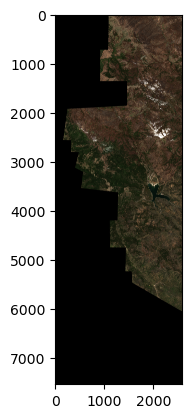

In [28]:
### visualize an Image
path = '/Users/Geronimowalker/Desktop/mendocino_first_tci_image/cropped_T10SDJ_20210412T185911_TCI_10m.jp2'

with Image.open(path) as img:
        img_array = np.array(img)
        print("Original Shape:",img_array.shape)
        img_arr = cv2.resize(img_array, (6800,6800), interpolation = cv2.INTER_AREA) 
print("New Shape:",img_arr.shape)
plt.imshow(img)

## Neeed to resive these images
#### Model takes 400 by 400 input
#### copernicus images are cropped to irregular sizes
#### our method was to reshape the images into sizes that can be whole number divided into 400 by 400 patches

In [65]:
## Testing Patchify and Unpatchify

patches = patchify.patchify(img_arr,(400,400,3),step=400) 

# reshape patches to desired format
num_patches_y, num_patches_x, _, patch_height, patch_width, num_channels = patches.shape
reshaped_patches = patches.reshape(num_patches_y * num_patches_x, patch_height, patch_width, num_channels)

reshaped_patches.shape

(289, 400, 400, 3)

## reshape images from patches to visualize

In [66]:
def reconstruct_image_from_patches(patches, patch_size=(400, 400), image_shape=(6800, 6800, 3)):
    num_patches = patches.shape[0]
    patch_height, patch_width = patch_size
    num_channels = patches.shape[3]
    
    # determine the number of patches per dimension
    num_patches_y = num_patches_x = int(np.sqrt(num_patches))

    # initialize the empty image array
    reconstructed_image = np.zeros(image_shape, dtype=np.float32)

    # place patches into the reconstructed image
    for i in range(num_patches_y):
        for j in range(num_patches_x):
            start_x, start_y = j * patch_width, i * patch_height
            end_x, end_y = start_x + patch_width, start_y + patch_height
            reconstructed_image[start_y:end_y, start_x:end_x, :] = patches[i * num_patches_x + j]

    return reconstructed_image

patches = reshaped_patches
patch_size = (400, 400)
image_shape = (6800, 6800, 3)

reconstructed_image = reconstruct_image_from_patches(patches, patch_size=patch_size, image_shape=image_shape)


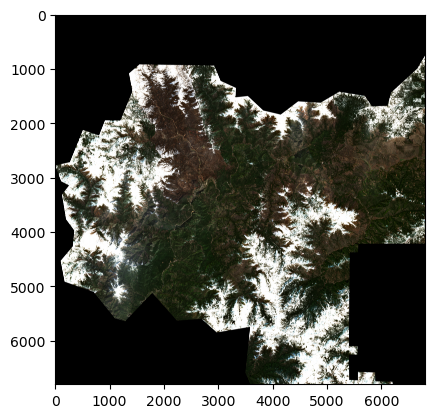

In [74]:
patch_size = (400, 400)
image_shape = (6800, 6800, 3)

reconstructed_image = reconstruct_image_from_patches(patches, patch_size=patch_size, image_shape=image_shape)

plt.imshow(reconstructed_image.astype(np.uint8))

## Update chunking function to resize image first

In [49]:
from rasterio.enums import Resampling

def process_and_save_chunks(image_path, output_dir, resize_shape=(6800, 6800), chunk_size=400):
    # open the image file
    with rasterio.open(image_path) as src:
        # find number of bands
        num_bands = src.count
        band_indices = list(range(1, num_bands + 1))

        
        image_data = np.stack([src.read(band) for band in band_indices], axis=0)

        # resize image
        resized_image_data = np.zeros((num_bands, resize_shape[1], resize_shape[0]), dtype=np.float32)
        for band in range(num_bands):
            resized_image_data[band] = cv2.resize(image_data[band], (resize_shape[0], resize_shape[1]), interpolation=cv2.INTER_AREA)

        # update image profile
        profile = src.profile.copy()
        profile.update({
            'height': resize_shape[1],
            'width': resize_shape[0],
            'transform': src.transform * src.transform.scale(
                (src.width / resize_shape[0]),
                (src.height / resize_shape[1])
            )
        })

        # function to define chunks along x and y axis
        num_chunks_x = (resize_shape[0] + chunk_size - 1) // chunk_size
        num_chunks_y = (resize_shape[1] + chunk_size - 1) // chunk_size

        # create and save chunks
        for i in range(num_chunks_y):
            for j in range(num_chunks_x):
                window = Window(j * chunk_size, i * chunk_size, chunk_size, chunk_size)
                chunk = resized_image_data[:, i * chunk_size:(i + 1) * chunk_size, j * chunk_size:(j + 1) * chunk_size]

                
                chunk_profile = profile.copy()
                chunk_profile.update({
                    'height': chunk.shape[1],
                    'width': chunk.shape[2],
                    'transform': rasterio.windows.transform(window, profile['transform'])
                })

                
                file_extension = os.path.splitext(image_path)[1]
                filename = os.path.join(output_dir, f"chunk_{i}_{j}{file_extension}")

                
                if not os.path.exists(output_dir):
                    os.makedirs(output_dir)

                # save chunk
                with rasterio.open(filename, 'w', **chunk_profile) as dst:
                    dst.write(chunk)
                
                print(f"Saved chunk to {filename}")



image_path = '/Users/Geronimowalker/Desktop/first_tci_image/cropped_T10TDL_20210206T190549_TCI_10m.jp2'
output_dir = '/Users/Geronimowalker/Desktop/image_chunks'

process_and_save_chunks(image_path, output_dir)

Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_0.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_1.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_2.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_3.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_4.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_5.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_6.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_7.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_8.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_9.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_10.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_11.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chunk_0_12.jp2
Saved chunk to /Users/Geronimowalker/Desktop/image_chunks/chu

In [4]:
# output dimensions
target_width = 6821
target_height = 6210

mask_path = '/Users/Geronimowalker/Desktop/deforestation_masks/other_TDL_20210721_TDL_20210929_deforestation.jp2'
output_path = '/Users/Geronimowalker/Desktop/deforestation_masks/correct_size_TDL_20210721_TDL_20210929_deforestation.jp2'

with rasterio.open(mask_path) as src:
        mask_data = src.read(1)
        
        
        resized_mask = cv2.resize(mask_data, (target_width, target_height), interpolation=cv2.INTER_NEAREST)


cv2.imwrite(output_path, resized_mask)


True

In [9]:

# output dimensions
target_height = 6916
target_width = 3633

mask_path = '/Users/Geronimowalker/Desktop/deforestation_masks/other_TEM_20210711_TEM_20210929_deforestation.jp2'
output_path = '/Users/Geronimowalker/Desktop/deforestation_masks/correct_size_TEM_20210711_TEM_20210929_deforestation.jp2'

with rasterio.open(mask_path) as src:
        mask_data = src.read(1)
        
        # resize
        resized_mask = cv2.resize(mask_data, (target_width, target_height), interpolation=cv2.INTER_NEAREST)


cv2.imwrite(output_path, resized_mask)



/Applications/anaconda3/envs/workenv/lib/python3.12/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


True

## Visualize images to test functionality

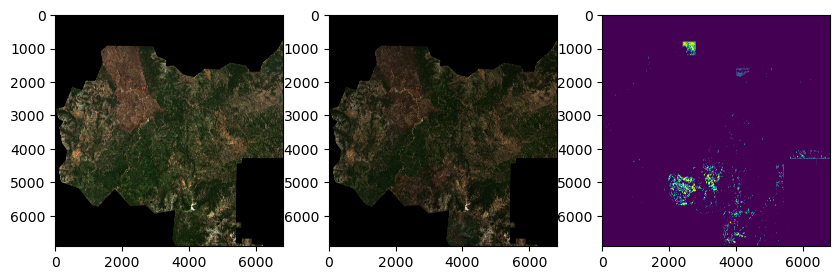

In [13]:
# early image, later image, deforestation mask
fig,axs = plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TDM_20210711T185921_TCI_10m.jp2')))
axs[1].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TDM_20210929T190201_TCI_10m.jp2')))
axs[2].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/deforestation_masks/correct_size__TDM_20210711_TDM_20210929_deforestation.jp2')))

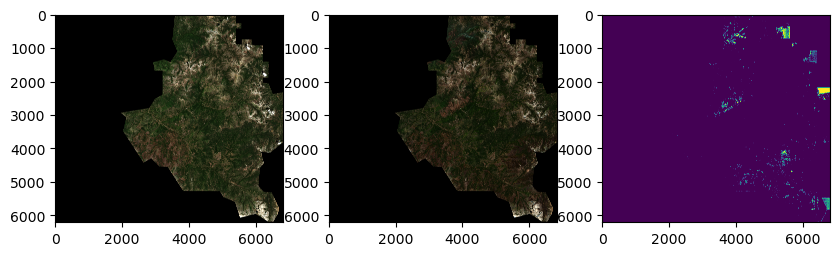

In [17]:
# early image, later image, deforestation mask
fig,axs = plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TDL_20210721T185921_TCI_10m.jp2')))
axs[1].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TDL_20210929T190201_TCI_10m.jp2')))
axs[2].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/deforestation_masks/correct_size_TDL_20210721_TDL_20210929_deforestation.jp2')))

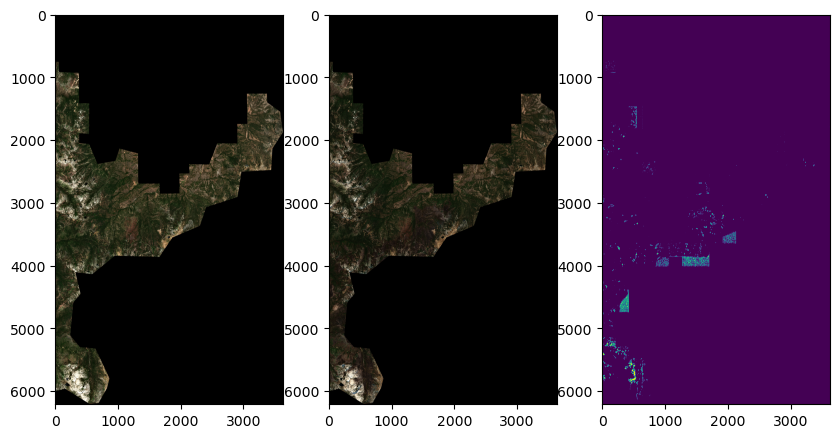

In [19]:
# early image, later image, deforestation mask
fig,axs = plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TEL_20210711T185921_TCI_10m.jp2')))
axs[1].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TEL_20210929T190201_TCI_10m.jp2')))
axs[2].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/deforestation_masks/correct_size_TEL_20210711_TEL_20210929_deforestation.jp2')))

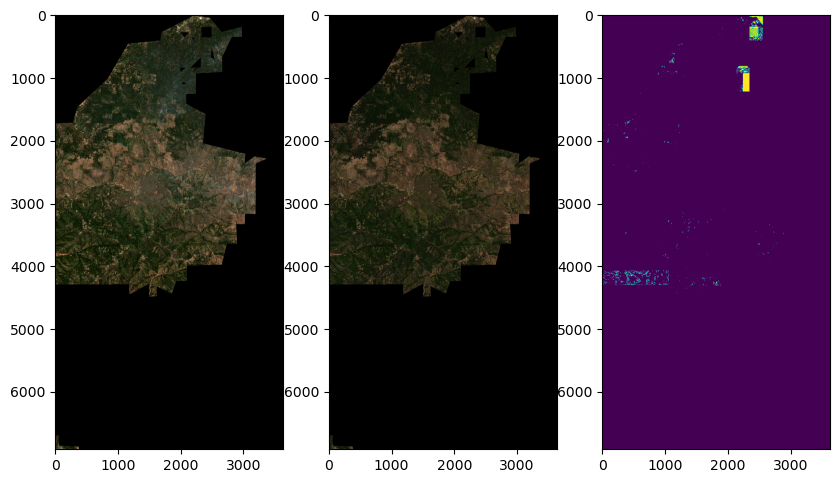

In [21]:
# early image, later image, deforestation mask
fig,axs = plt.subplots(1,3,figsize=(10,10))
axs[0].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TEM_20210711T185921_TCI_10m.jp2')))
axs[1].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TEM_20210929T190201_TCI_10m.jp2')))
axs[2].imshow(np.array(Image.open('/Users/Geronimowalker/Desktop/deforestation_masks/correct_size_TEM_20210711_TEM_20210929_deforestation.jp2')))

In [23]:
image = np.array(Image.open('/Users/Geronimowalker/Desktop/deforestation_masks/correct_size_TEM_20210711_TEM_20210929_deforestation.jp2'))

In [10]:
tdl = Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TDL_20210716T185919_TCI_10m.jp2')
tdm = Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TDM_20210716T185919_TCI_10m.jp2')
tel = Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TEL_20210716T185919_TCI_10m.jp2')
tem = Image.open('/Users/Geronimowalker/Desktop/last_tci_image/cropped_T10TEM_20210716T185919_TCI_10m.jp2')


In [17]:
eight = Image.open('/Users/Geronimowalker/Desktop/cropped_satellite_images_jan_june/S2A_MSIL2A_20210601T185921_N0500_R013_T10TDL_20230128T181749.SAFE/cropped_T10TDL_20210601T185921_B08_10m.jp2')
eight = np.array(eight)
four = Image.open('/Users/Geronimowalker/Desktop/cropped_satellite_images_jan_june/S2A_MSIL2A_20210601T185921_N0500_R013_T10TDL_20230128T181749.SAFE/cropped_T10TDL_20210601T185921_B04_10m.jp2')
four = np.array(four)



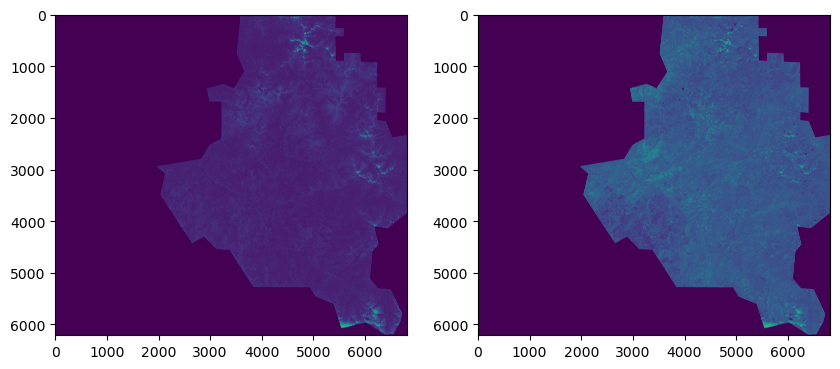

In [21]:
fig,axs= plt.subplots(1,2,figsize=(10,10))
axs[0].imshow(four)
axs[1].imshow(eight)

In [13]:
tem_wv_array = np.array(tem_wv)
tem_wv_array.shape

(6916, 6821)

Text(0.5, 1.0, 'tel')

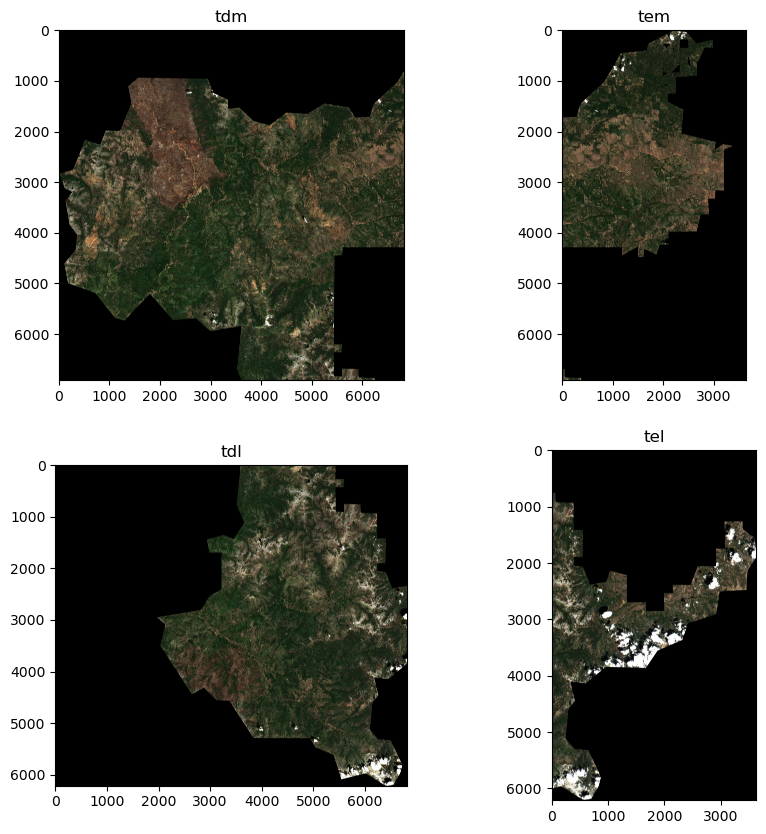

In [9]:
fig,axs = plt.subplots(2,2,figsize=(10,10))

axs[0,0].imshow(tdm)
axs[0,0].set_title('tdm')

axs[0,1].imshow(tem)
axs[0,1].set_title('tem')

axs[1,0].imshow(tdl)
axs[1,0].set_title('tdl')

axs[1,1].imshow(tel)
axs[1,1].set_title('tel')

